
### Ratio of Geometric means and survival analysis


In [95]:
import numpy as np
import pandas as pd
from lifelines import KaplanMeierFitter
import matplotlib.pyplot as plt

In [96]:
clin_outcome = pd.read_csv('clinical_outcomes.csv',index_col = 0)
# this has 2 sheets, one sheet w/o 43 and sheet2 with 43

In [97]:
clin_outcome.head()

,PFS (days),Event,Time to 2nd prog,Time to Off Study,IO Status,PD-L1 status,Dose Level,Best Response,Time to off study (Weeks),Clinical Benefit at 24 Weeks?,BR_bool,IO_bool,Spat_metric
Seq. #,,,,,,,,,,,,,
33,68,1,130,136,Relapsed,2,2,0,19.428571,0,0,0,1.878515
34,345,0,0,345,Relapsed,2,2,0,49.285714,1,0,0,1.601031
36,11,1,0,24,Refractory,0,2,1,3.428571,0,1,1,0.315040
37,330,0,0,330,Relapsed,1,2,0,47.142857,1,0,0,2.002188
41,46,1,0,46,Relapsed,1,2,1,6.571429,0,1,0,0.282782


In [98]:
clin_outcome.shape

(8, 13)

In [99]:
clin_outcome.dtypes


PFS (days)                         int64
Event                              int64
Time to 2nd prog                   int64
Time to Off Study                  int64
IO Status                         object
PD-L1 status                       int64
Dose Level                         int64
Best Response                      int64
Time to off study (Weeks)        float64
Clinical Benefit at 24 Weeks?      int64
BR_bool                            int64
IO_bool                            int64
Spat_metric                      float64
dtype: object

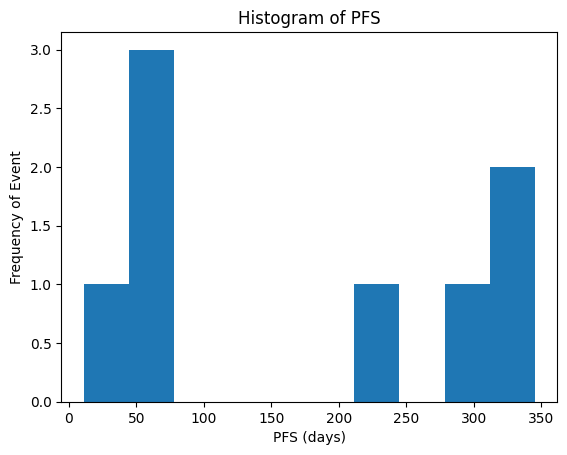

In [100]:
T = clin_outcome["PFS (days)"]
E = clin_outcome["Event"]
plt.hist(T, bins = 10)
plt.xlabel('PFS (days)')
plt.ylabel('Frequency of Event')
plt.title('Histogram of PFS')
plt.show()


Text(0.5, 1.0, 'KM Plot with 95% CI')

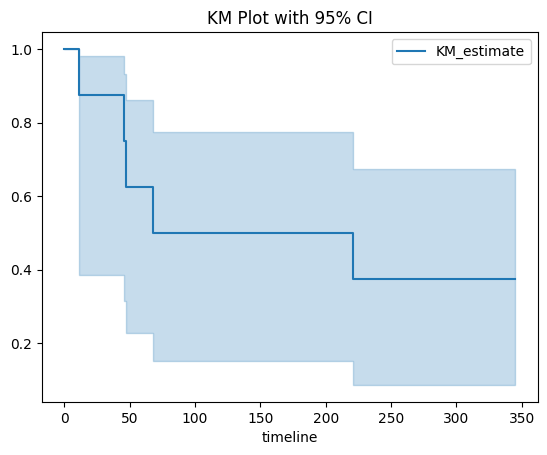

In [101]:
kmf = KaplanMeierFitter()
kmf.fit(durations = T, event_observed = E)
kmf.plot_survival_function()
# 
plt.title('KM Plot with 95% CI')

Text(0.5, 1.0, 'Survival function')

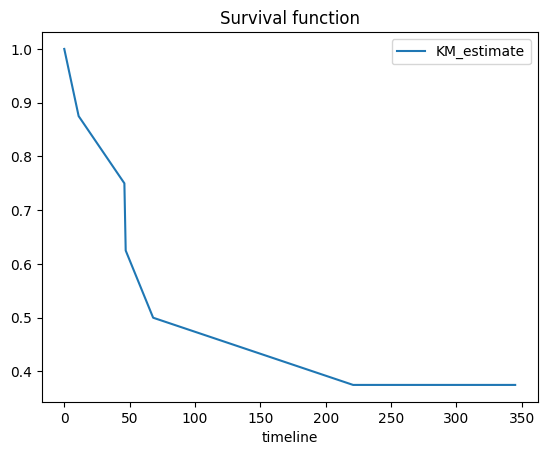

In [102]:
kmf.survival_function_.plot()
plt.title('Survival function')

<Axes: xlabel='timeline'>

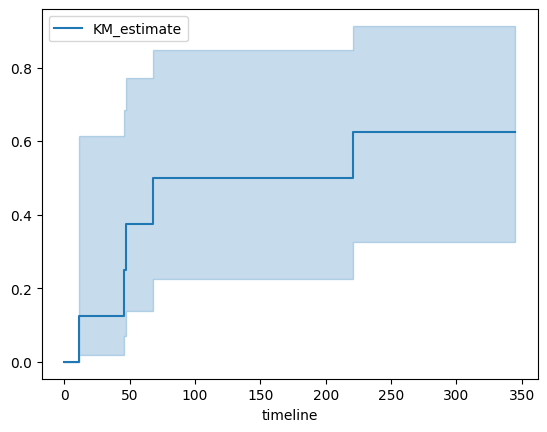

In [103]:
#
#plot a failure curve. 
# It is just opposite of survival, i.e., Failure/death probabilities over time.
kmf.plot_cumulative_density()

In [104]:
from lifelines.utils import median_survival_times
median_ = kmf.median_survival_time_
median_confidence_interval_ = median_survival_times(kmf.confidence_interval_)
print(median_)
print(median_confidence_interval_)

221.0
     KM_estimate_lower_0.95  KM_estimate_upper_0.95
0.5                    11.0                     inf


In [105]:
# Here, the median survival time is 68 days, 
# which indicates that 50% of the sample live 68 days and 50% dies within this time. 
# The 95% CI lower limit is 11 days, while the upper limit is inf days.

In [106]:
#clin_outcome['Best Response'] = 
clin_outcome['Best Response'].astype('category')

Seq. #
33    0
34    0
36    1
37    0
41    1
44    0
47    0
54    1
Name: Best Response, dtype: category
Categories (2, int64): [0, 1]

#### OS with best response (SD or PD)

Text(0.5, 1.0, 'Survival of different Response groups')

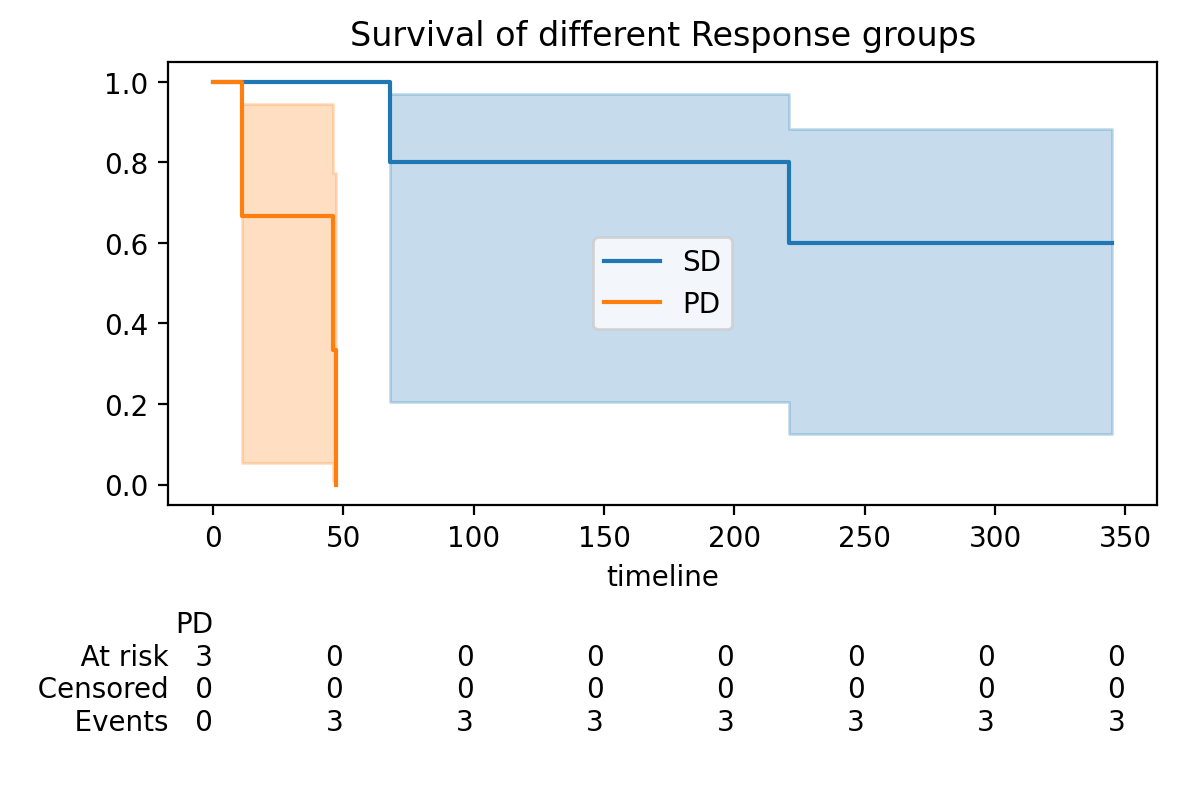

In [163]:
# overall survival from before split into sd and pd
#fig, ax = plt.subplots(figsize=[7,5],dpi=150)
fig, ax = plt.subplots(figsize=[6,4], dpi= 200)
m = (clin_outcome["Best Response"] == 0)
kmf.fit(durations = T[m], event_observed = E[m], label = "SD")
kmf.plot_survival_function(ax = ax)#, at_risk_counts = True)
kmf.fit(T[~m], event_observed = E[~m], label = "PD")
kmf.plot_survival_function(ax = ax, at_risk_counts = True)
plt.title("Survival of different Response groups")

#### OS with best response (SD or PD)
##### based on PDL1 status (0, 1, 2, 3) # if no 43, then only 0, 1, 2

Seq. #
33    False
34    False
36     True
37    False
41    False
44     True
47    False
54    False
Name: PD-L1 status, dtype: bool
Seq. #
33    False
34    False
36    False
37     True
41     True
44    False
47    False
54     True
Name: PD-L1 status, dtype: bool
Seq. #
33     True
34     True
36    False
37    False
41    False
44    False
47     True
54    False
Name: PD-L1 status, dtype: bool


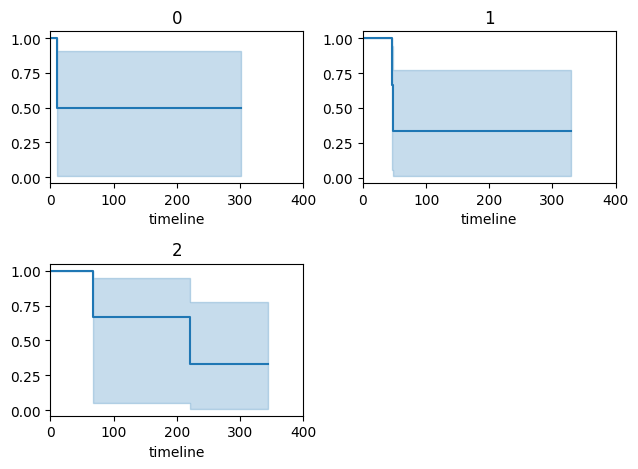

In [112]:
#pfs split into pdl1 status, all patients

pdl1_types = clin_outcome.sort_values(by = ['PD-L1 status'])["PD-L1 status"].unique()
for i, pdl1_types in enumerate(pdl1_types):
  ax = plt.subplot(2, 2, i + 1)
  ix = clin_outcome['PD-L1 status'] == pdl1_types
  print(ix)
  kmf.fit(T[ix], E[ix], label = pdl1_types)
  kmf.plot_survival_function(ax = ax, legend = False)
  plt.title(pdl1_types)
  plt.xlim(0, 400)
plt.tight_layout()

#### OS with best response (SD or PD) and pdl1 

0
1
2


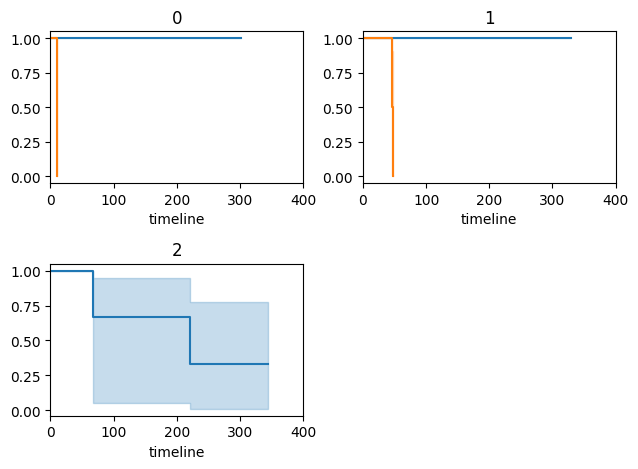

In [114]:
#pfs split into pdl1 status as well as sd and pd

pdl1_types = clin_outcome.sort_values(by = ['PD-L1 status'])["PD-L1 status"].unique()


for i, pdl1_types in enumerate(pdl1_types):

  print(i)
  if (i !=3):
      ax = plt.subplot(2, 2, i + 1)
      ix = clin_outcome['PD-L1 status'] == pdl1_types
    
    
      m = (clin_outcome["Best Response"] == 0)
      ixm = ix * m
      kmf.fit(T[ixm], E[ixm], label = 'SD')
      kmf.plot_survival_function(ax = ax, legend = False)
    
      m = (clin_outcome["Best Response"] == 1)
      ixm = ix * m
      if (ixm.any()==True): #added this since subset 2 only had sd patients
          kmf.fit(T[ixm], E[ixm], label = 'PD')
          kmf.plot_survival_function(ax = ax, legend = False)
      
    
      plt.title(pdl1_types)
      plt.xlim(0, 400)
      
plt.tight_layout()
#plt.title("Survival of different Response groups")

#### OS with best response (SD or PD) and spat metric

In [1]:
## Goal is to show another metric or value per patient, that can now be split into sd and pd
## for example, cd8+pdl1+cd3 and foxp3+pd1

Seq. #
33     True
34     True
36    False
37     True
41    False
44     True
47     True
54    False
Name: BR_bool, dtype: bool
Seq. #
33    False
34    False
36     True
37    False
41     True
44    False
47    False
54     True
Name: BR_bool, dtype: bool


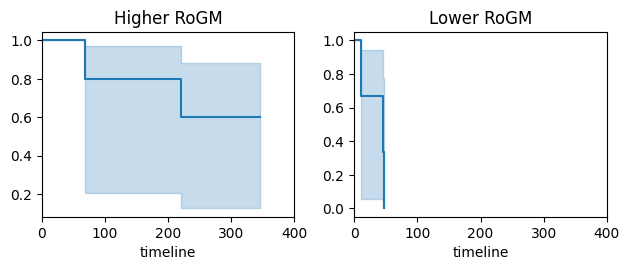

In [144]:
#pfs split into spat_met, all patients
## We use BR bool (which is equiv to cutting the spat metric at 0.5 threshold)


spat_met_label=['Higher RoGM','Lower RoGM']
spat_met = clin_outcome.sort_values(by = ['BR_bool'])["BR_bool"].unique()
for i, spat_met in enumerate(spat_met):
  ax = plt.subplot(2, 2, i + 1)
  ix = clin_outcome['BR_bool'] == spat_met
  print(ix)
  kmf.fit(T[ix], E[ix], label = spat_met)
  kmf.plot_survival_function(ax = ax, legend = False)
  plt.title(spat_met_label[i])
  plt.xlim(0, 400)
plt.tight_layout()

Text(0.5, 1.0, 'Survival of patients based on RoGM')

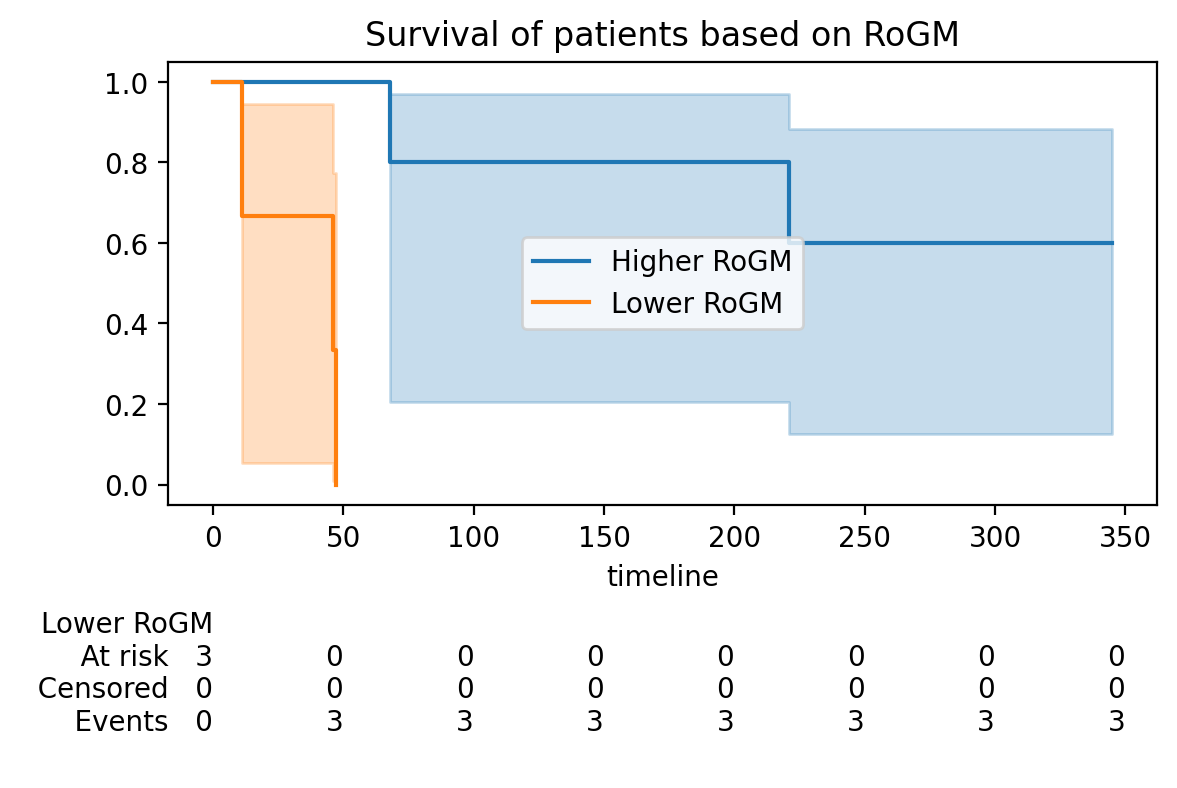

In [181]:
# overall survival based on spat metric cut at 0.5
fig, ax = plt.subplots(figsize=[6,4], dpi= 200)
#ax = plt.subplot(111)
m = (clin_outcome["BR_bool"] == 0)
kmf.fit(durations = T[m], event_observed = E[m], label = "Higher RoGM")
#plt.legend(loc=8)
kmf.plot_survival_function(ax = ax)#, at_risk_counts = True)
kmf.fit(T[~m], event_observed = E[~m], label = "Lower RoGM")
kmf.plot_survival_function(ax = ax, at_risk_counts = True)
#ax.legend(loc=11)
plt.title("Survival of patients based on RoGM") 
